# Notebook 4a — EDA y Estadística descriptiva — **SOLO granja VC30D**
### Tuberculosis bovina

**Cohorte:** `BD.csv` restringida a la **explotación VC30D** (n=55 tras limpieza inicial,
posiblemente menos tras eliminar filas con ≥4 NAs en predictores).

**Motivación:** VC30D es la granja más grande de la cohorte y el análisis intra-granja
elimina el confusor inter-granja. Este notebook replica el EDA del `01_EDA_Estadistica.ipynb`
completo pero **sin variación inter-granja**: todas las diferencias observadas son
genuinamente intra-explotación.

**Comparar con Notebook 1 (cohorte completa)** para ver qué señales son propias de
VC30D y cuáles eran artefactos de la mezcla entre granjas.

> **Hallazgos estructurales del dataset completo relevantes para VC30D:**
> 1. **Una sola explotación** → no hay confusor inter-granja; validación por animal.
> 2. **Targets condicionales:** `Patron_lesiones` solo definido en lesionados.
> 3. **n reducido** dentro de VC30D: más varianza, menor potencia estadística.
> 4. **Todas las continuas rechazan normalidad** → estadística no paramétrica.

**Figuras:** guardadas en `figures/` con prefijo `fig_04a_`.

## 1. Dependencias, reproducibilidad y carga

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import tb_utils as tb
PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

GRANJA   = "VC30D"
DATA_PATH = "../BD.csv"

# Carga y limpieza completa, luego filtrar a VC30D
raw = tb.load_raw(DATA_PATH)
df_full = tb.clean(raw)
print(f"Dataset completo: {df_full.shape[0]} animales, {df_full.shape[1]} variables")
print(f"Granjas disponibles: {sorted(df_full[tb.GROUP_COL].unique())}")

df = df_full[df_full[tb.GROUP_COL] == GRANJA].copy().reset_index(drop=True)
print(f"\nExplotación {GRANJA}: {df.shape[0]} animales antes de filtrar NAs")
df.head()

Dataset completo: 106 animales, 20 variables
Granjas disponibles: ['VA32D', 'VC30D', 'VC94C', 'WZ72B']

Explotación VC30D: 55 animales antes de filtrar NAs


,Ide,Expl,Lesiones,Localizacion,Lesiones_TB,Patron_lesiones,Score_lesional,PIROPLASMA,THEILERIA,ANAPLASMA,VITAMINA_D,CALCIO,PIROPLASMA_Q,EDAD,SEXO,RAZA,IDTC,PIROPLASMA_Q_log,RAZA2,Patron_lesiones_3
0,219743218,VC30D,Lesão caseosa,Pulmonar + linfodonos retrofaríngeos,1,1.0,4,1.0,0.0,0.0,30.095327,0.925870,4386.325854,3,F,Cruzado,23,8.386475,Cruzado,1
1,19141978,VC30D,Não apresentava lesões,Sem lesão,0,NaN,0,1.0,1.0,1.0,28.809805,0.925330,5121.251766,4,F,Cruzado,6,8.541349,Cruzado,-1
2,419913399,VC30D,Lesão,Linfonodos retrofaríngeos,1,0.0,1,0.0,0.0,1.0,16.124517,0.916724,0.000000,3,F,Cruzado,18,0.000000,Cruzado,0
3,314429794,VC30D,Lesão caseosa,Linfonodos mediastinicos,1,0.0,2,1.0,0.0,1.0,25.561307,0.907463,3869.100402,11,F,Cruzado,23,8.261036,Cruzado,0
4,17717137,VC30D,Não apresentava lesões,Sem lesão,0,NaN,0,1.0,0.0,1.0,17.302274,0.943350,5775.378886,6,F,Cruzado,13,8.661532,Cruzado,-1


## 2. Diccionario de variables y targets

| Variable | Rol | Tipo | Nota |
|---|---|---|---|
| `Expl` | grupo | nominal | Solo VC30D en este notebook |
| `Lesiones_TB` | **Target 1** | binaria | 1=lesión, 0=sin lesión |
| `Patron_lesiones` | **Target 2** | binaria | 0=localizado, 1=generalizado (**solo lesionados**) |
| `Score_lesional` | **Target 3** | ordinal | {0,1,2,4,5} (sin 3; 0=sin lesión) |
| `IDTC` | **Target 4** | recuento | mm — prueba intradérmica comparada |
| `PIROPLASMA/THEILERIA/ANAPLASMA` | predictor | binaria | serología +/− |
| `VITAMINA_D, CALCIO, PIROPLASMA_Q, EDAD` | predictor | continua | PIROPLASMA_Q muy asimétrica → log1p |
| `SEXO, RAZA` | predictor | nominal | casi degeneradas |

> **Nota:** sin variación de `Expl` en este subconjunto, la explotación no es
> informativa como predictor (constante = VC30D).

In [2]:
print(f"Target 1 — Lesiones_TB ({GRANJA}):")
print(df["Lesiones_TB"].value_counts().rename({0:"Sin lesión",1:"Con lesión"}).to_string())
print(f"  Prevalencia lesión = {df['Lesiones_TB'].mean():.3f}\n")

les = df[df.Lesiones_TB==1]
print(f"Target 2 — Patron_lesiones (solo lesionados, n={len(les)}):")
print(les["Patron_lesiones"].value_counts().rename({0:"Localizado",1:"Generalizado"}).to_string())
prev_gen = les["Patron_lesiones"].mean()
print(f"  Prevalencia generalizado = {prev_gen:.3f}\n")

print("Target 3 — Score_lesional (atención: sin categoría 3):")
print(df["Score_lesional"].value_counts().sort_index().to_string(), "\n")

print("Target 4 — IDTC (mm):")
print(df["IDTC"].describe()[["min","25%","50%","75%","max","mean","std"]].round(2).to_string())

Target 1 — Lesiones_TB (VC30D):
Lesiones_TB
Con lesión    32
Sin lesión    23
  Prevalencia lesión = 0.582

Target 2 — Patron_lesiones (solo lesionados, n=32):
Patron_lesiones
Localizado      24
Generalizado     8
  Prevalencia generalizado = 0.250

Target 3 — Score_lesional (atención: sin categoría 3):
Score_lesional
0    23
1    13
2     6
4     8
5     5 

Target 4 — IDTC (mm):
min      5.00
25%      6.00
50%     10.00
75%     13.50
max     26.00
mean    11.25
std      5.90


## 3. Estructura interna de VC30D

Sin variación entre granjas, exploramos la variación interna por otras variables
de agrupación: **raza** y **edad** (grupos etarios). También comparamos la
distribución de targets en VC30D vs el resto de la cohorte.

In [3]:
print(f"=== Estructura de {GRANJA} ===")
print(f"n total: {len(df)}")
print(f"Lesiones_TB: {df['Lesiones_TB'].sum()} con lesión ({df['Lesiones_TB'].mean():.1%})")
print(f"Score_lesional — media: {df['Score_lesional'].mean():.2f}, mediana: {df['Score_lesional'].median():.1f}")
print(f"IDTC — media: {df['IDTC'].mean():.2f} mm, mediana: {df['IDTC'].median():.1f} mm")

print(f"\n=== Distribución RAZA en {GRANJA} ===")
print(df["RAZA2"].value_counts().to_string())

print(f"\n=== Distribución SEXO en {GRANJA} ===")
print(df["SEXO"].value_counts().to_string())

# Grupos etarios
df["EDAD_grupo"] = pd.cut(df["EDAD"], bins=[0, 3, 6, 10, 100],
                           labels=["1-3 años","4-6 años","7-10 años",">10 años"])
print(f"\n=== Grupos etarios en {GRANJA} ===")
print(df.groupby("EDAD_grupo", observed=True)[["Lesiones_TB","IDTC","Score_lesional"]]
        .agg(["size","mean"]).round(3).to_string())

# Comparación VC30D vs resto
df_rest = df_full[df_full[tb.GROUP_COL] != GRANJA].copy()
print(f"\n=== {GRANJA} vs resto de granjas ===")
compare = pd.DataFrame({
    GRANJA:  {"n": len(df), "prev_lesion": df["Lesiones_TB"].mean(),
              "idtc_med": df["IDTC"].median(), "score_med": df["Score_lesional"].median()},
    "Resto": {"n": len(df_rest), "prev_lesion": df_rest["Lesiones_TB"].mean(),
              "idtc_med": df_rest["IDTC"].median(), "score_med": df_rest["Score_lesional"].median()},
}).T
print(compare.round(3).to_string())

=== Estructura de VC30D ===
n total: 55
Lesiones_TB: 32 con lesión (58.2%)
Score_lesional — media: 1.49, mediana: 1.0
IDTC — media: 11.25 mm, mediana: 10.0 mm

=== Distribución RAZA en VC30D ===
RAZA2
Cruzado       44
Alentejana    10
Otra           1

=== Distribución SEXO en VC30D ===
SEXO
F    53
M     2

=== Grupos etarios en VC30D ===
           Lesiones_TB        IDTC         Score_lesional       
                  size   mean size    mean           size   mean
EDAD_grupo                                                      
1-3 años            16  0.625   16  12.125             16  1.312
4-6 años            16  0.375   16  11.000             16  1.062
7-10 años           15  0.733   15   9.467             15  2.133
>10 años             8  0.625    8  13.375              8  1.500

=== VC30D vs resto de granjas ===
          n  prev_lesion  idtc_med  score_med
VC30D  55.0        0.582      10.0        1.0
Resto  51.0        0.647      10.0        1.0


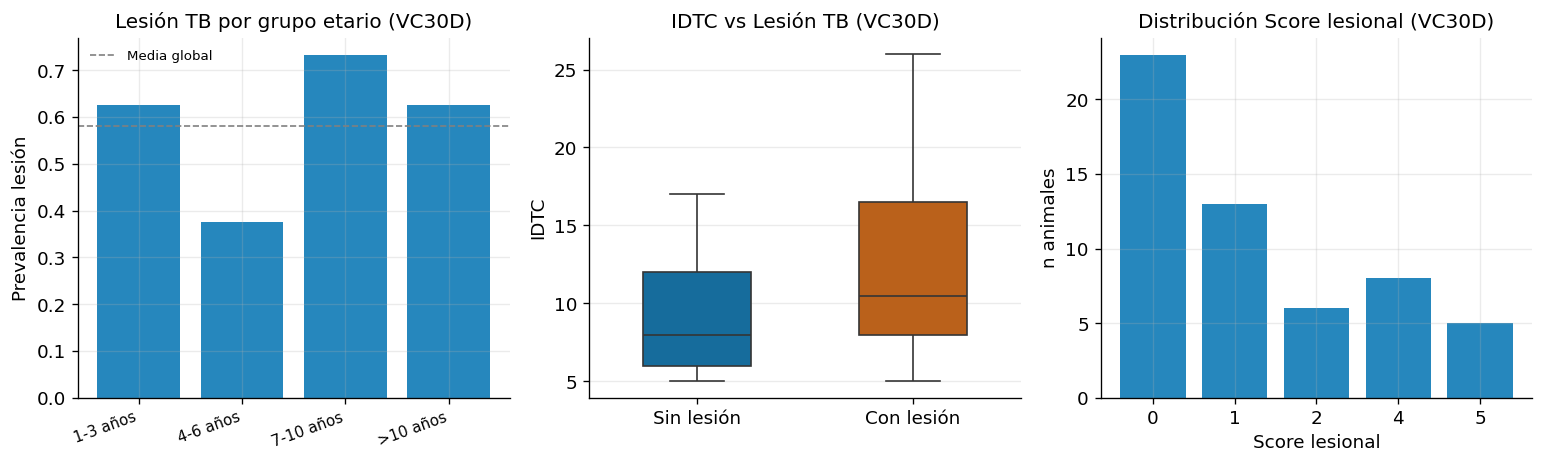

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Prevalencia lesión por grupo etario
prev_edad = df.groupby("EDAD_grupo", observed=True)["Lesiones_TB"].mean()
axes[0].bar(range(len(prev_edad)), prev_edad.values, color=PALETTE[0], alpha=0.85)
axes[0].set_xticks(range(len(prev_edad)))
axes[0].set_xticklabels(prev_edad.index, rotation=20, ha="right", fontsize=9)
axes[0].set_ylabel("Prevalencia lesión")
axes[0].set_title(f"Lesión TB por grupo etario ({GRANJA})")
axes[0].axhline(df["Lesiones_TB"].mean(), color="grey", ls="--", lw=1, label="Media global")
axes[0].legend(fontsize=8)

# Distribución IDTC por lesión
sns.boxplot(data=df, x="Lesiones_TB", y="IDTC", ax=axes[1], palette=PALETTE[:2], width=0.5)
axes[1].set_xticklabels(["Sin lesión", "Con lesión"])
axes[1].set_title(f"IDTC vs Lesión TB ({GRANJA})")
axes[1].set_xlabel("")

# Distribución Score_lesional
sc = df["Score_lesional"].value_counts().sort_index()
axes[2].bar(sc.index.astype(str), sc.values, color=PALETTE[0], alpha=0.85)
axes[2].set_xlabel("Score lesional")
axes[2].set_ylabel("n animales")
axes[2].set_title(f"Distribución Score lesional ({GRANJA})")

plt.tight_layout()
plt.savefig("figures/fig_04a_internal_structure.png", bbox_inches="tight")
plt.show()

## 4. Análisis de datos faltantes (missingness)

Estrategia idéntica al notebook completo:
- Ausencia en `Patron_lesiones` → estructural (no lesionados), imputar −1.
- Filas con ≥4 NAs en predictores → eliminar.
- Ausencia en serología/bioquímica → gestionar **dentro** de CV, nunca antes.

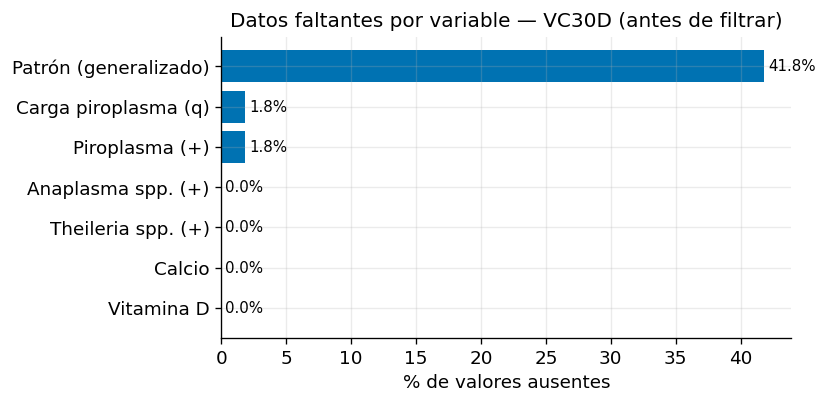

Filas con ≥4 NAs en predictores: 0

Dataset VC30D tras filtrado: 55 animales (eliminados 0)

Patron_lesiones (−1=no lesión, 0=local., 1=general.):
Patron_lesiones
No lesión (-1)      23
Localizado (0)      24
Generalizado (1)     8


In [5]:
pred_vars = tb.BIN_SEROLOGY + ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q"]

# Missingness antes de filtrar
na_before = df[pred_vars + ["Patron_lesiones"]].isna().mean()
na_before = na_before.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(range(len(na_before)), na_before.values * 100, color=PALETTE[0])
ax.set_yticks(range(len(na_before)))
ax.set_yticklabels([tb.PRETTY.get(i, i) for i in na_before.index])
ax.set_xlabel("% de valores ausentes")
ax.set_title(f"Datos faltantes por variable — {GRANJA} (antes de filtrar)")
for i, v in enumerate(na_before.values * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("figures/fig_04a_missingness_before.png")
plt.show()

# Filas con ≥4 NAs
na_per_row = df[pred_vars].isna().sum(axis=1)
mask_drop  = na_per_row >= 4
print(f"Filas con ≥4 NAs en predictores: {mask_drop.sum()}")
if mask_drop.any():
    print(df[mask_drop][["Ide", "Expl", "Lesiones_TB"] + pred_vars].to_string())

df = df[~mask_drop].copy().reset_index(drop=True)
print(f"\nDataset {GRANJA} tras filtrado: {len(df)} animales (eliminados {mask_drop.sum()})")

# Imputar Patron_lesiones = -1 para no lesionados
df["Patron_lesiones"] = df["Patron_lesiones"].fillna(-1).astype(int)
print("\nPatron_lesiones (−1=no lesión, 0=local., 1=general.):")
print(df["Patron_lesiones"].value_counts().sort_index()
      .rename({-1: "No lesión (-1)", 0: "Localizado (0)", 1: "Generalizado (1)"}).to_string())

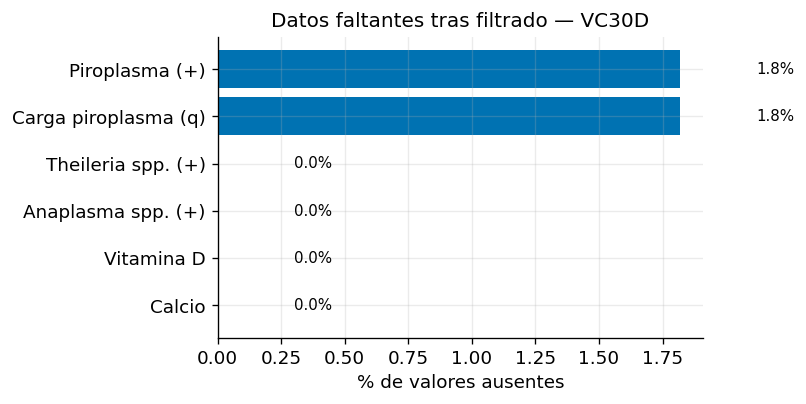


Patron_lesiones × Lesiones_TB en VC30D:
Patrón  General.(1)  Local.(0)  No lesión(-1)
Lesión                                       
0                 0          0             23
1                 8         24              0


In [6]:
na_after = df[pred_vars].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(range(len(na_after)), na_after.values * 100, color=PALETTE[0])
ax.set_yticks(range(len(na_after)))
ax.set_yticklabels([tb.PRETTY.get(i, i) for i in na_after.index])
ax.set_xlabel("% de valores ausentes")
ax.set_title(f"Datos faltantes tras filtrado — {GRANJA}")
for i, v in enumerate(na_after.values * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("figures/fig_04a_missingness_after.png")
plt.show()

print(f"\nPatron_lesiones × Lesiones_TB en {GRANJA}:")
print(pd.crosstab(df.Lesiones_TB, df.Patron_lesiones.map({-1:"No lesión(-1)",0:"Local.(0)",1:"General.(1)"}),
                  rownames=["Lesión"], colnames=["Patrón"]).to_string())

## 5. Descriptivos univariantes

In [7]:
print(f"=== Continuas — {GRANJA} (n={len(df)}) ===\n")
desc = []
for c in ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q", "EDAD", "IDTC", "Score_lesional"]:
    x = df[c].dropna()
    stat, p = stats.shapiro(x)
    desc.append(dict(
        variable   = tb.PRETTY.get(c, c),
        n          = len(x),
        mediana    = round(float(np.median(x)), 3),
        IQR        = f"[{np.percentile(x,25):.2f}, {np.percentile(x,75):.2f}]",
        min        = round(float(x.min()), 3),
        max        = round(float(x.max()), 3),
        shapiro_p  = round(float(p), 4),
    ))
print(pd.DataFrame(desc).to_string(index=False))
print("\n→ Verificar normalidad; si p<0.05 → tests no paramétricos.")

print(f"\n=== Binarias/nominales — {GRANJA} ===")
for c in ["PIROPLASMA", "THEILERIA", "ANAPLASMA", "RAZA2", "SEXO"]:
    vc = df[c].value_counts(dropna=False)
    print(f"  {tb.PRETTY.get(c, c):25s}: {dict(vc.head(5))}")

=== Continuas — VC30D (n=55) ===

            variable  n  mediana               IQR   min       max  shapiro_p
          Vitamina D 55   21.773    [15.77, 28.58] 0.078    53.261     0.0116
              Calcio 55    0.923      [0.91, 0.94] 0.824     0.974     0.0037
Carga piroplasma (q) 54 1426.877 [419.23, 3915.26] 0.000 17152.953     0.0000
         Edad (años) 55    6.000      [3.00, 8.00] 1.000    14.000     0.0115
     Intensidad IDTC 55   10.000     [6.00, 13.50] 5.000    26.000     0.0000
      Score lesional 55    1.000      [0.00, 2.00] 0.000     5.000     0.0000

→ Verificar normalidad; si p<0.05 → tests no paramétricos.

=== Binarias/nominales — VC30D ===
  Piroplasma (+)           : {1.0: np.int64(52), 0.0: np.int64(2), nan: np.int64(1)}
  Theileria spp. (+)       : {1.0: np.int64(29), 0.0: np.int64(26)}
  Anaplasma spp. (+)       : {1.0: np.int64(39), 0.0: np.int64(16)}
  Raza                     : {'Cruzado': np.int64(44), 'Alentejana': np.int64(10), 'Otra': np.int64(1)}

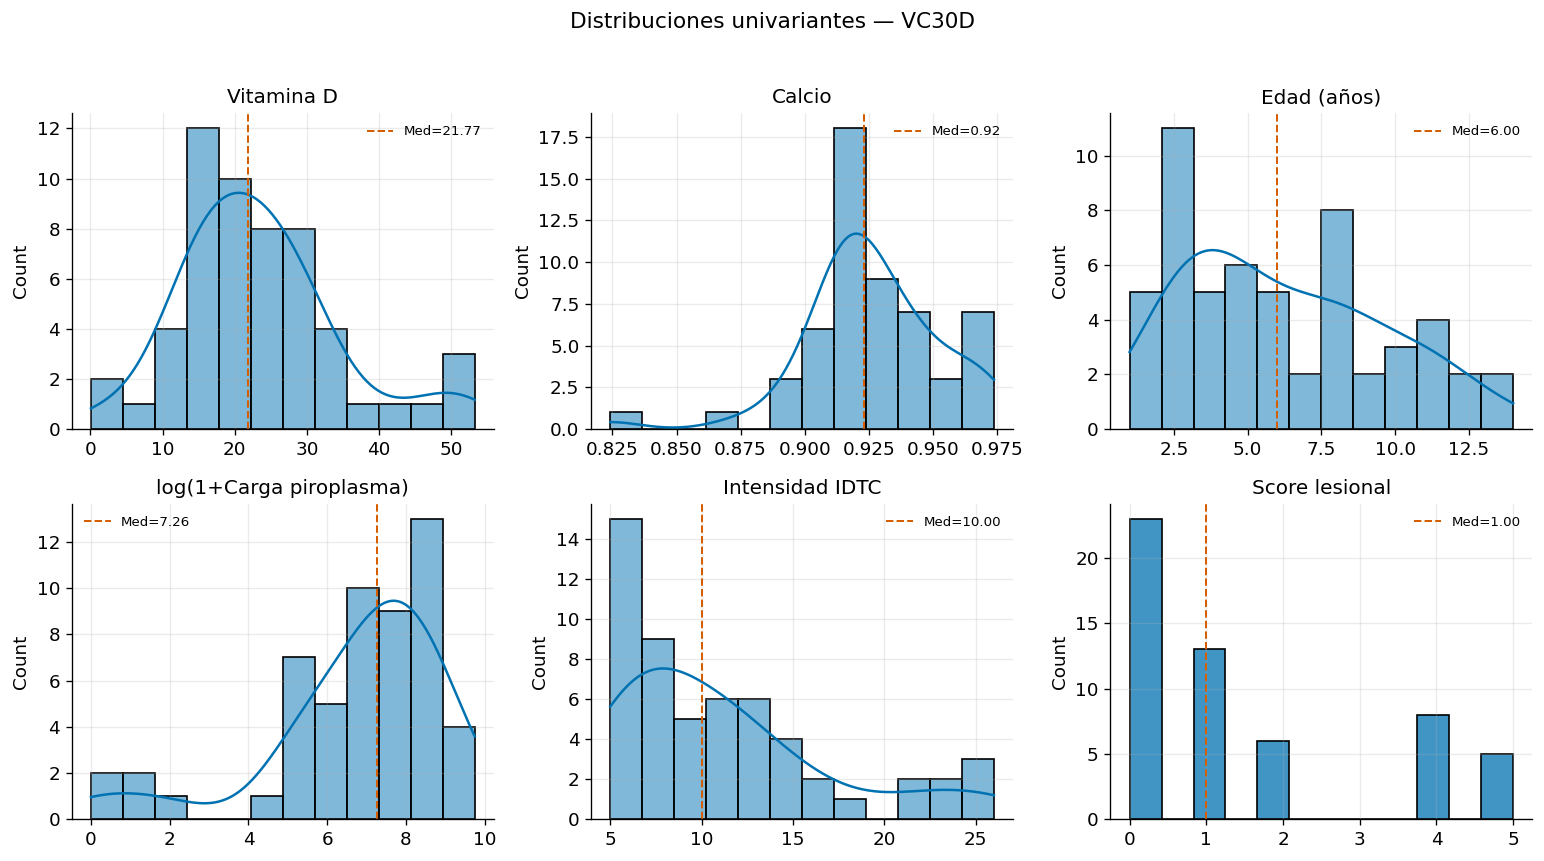

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(),
                  ["VITAMINA_D", "CALCIO", "EDAD", "PIROPLASMA_Q_log", "IDTC", "Score_lesional"]):
    data = df[c].dropna()
    sns.histplot(data, kde=(data.nunique() > 10), color=PALETTE[0], ax=ax, bins=12)
    ax.set_title(tb.PRETTY.get(c, c))
    ax.set_xlabel("")
    med = data.median()
    ax.axvline(med, color=PALETTE[1], ls="--", lw=1.2, label=f"Med={med:.2f}")
    ax.legend(fontsize=8)
plt.suptitle(f"Distribuciones univariantes — {GRANJA}", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figures/fig_04a_univariate.png", bbox_inches="tight")
plt.show()

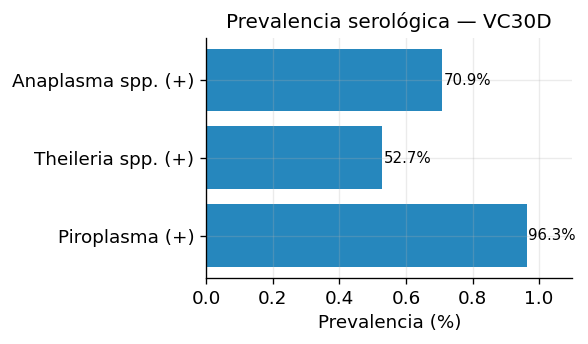

In [9]:
# Prevalencias serología
bin_cols = ["PIROPLASMA", "THEILERIA", "ANAPLASMA"]
prev_ser = {tb.PRETTY.get(c, c): df[c].mean() for c in bin_cols if df[c].notna().any()}
fig, ax = plt.subplots(figsize=(5, 3))
ax.barh(list(prev_ser.keys()), list(prev_ser.values()), color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Prevalencia (%)")
ax.set_title(f"Prevalencia serológica — {GRANJA}")
for i, v in enumerate(prev_ser.values()):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.savefig("figures/fig_04a_serology_prevalence.png")
plt.show()

## 6. Comparaciones bivariantes vs cada target

Tests seleccionados según tipo y normalidad:
- Continuas → **Mann–Whitney U** (no normales) con **Cliff's δ** + IC bootstrap.
- Binarias/nominales → **Fisher** (celdas <5) o **χ²** con **Cramér's V**.
- Corrección **FDR (Benjamini–Hochberg)** dentro de cada familia.

> **Advertencia de potencia:** con n≈50 y múltiple corrección, la potencia es baja.
> Asociaciones nominalmente significativas pero FDR>0.05 son señales débiles y
> deben validarse con el modelo (notebooks 04c–04f).

In [10]:
# --- Target 1: Lesiones_TB ---
res_les = tb.bivariate_vs_binary(df, "Lesiones_TB")
print(f"Lesiones_TB ~ predictores — {GRANJA} (n={len(df)}):")
print(res_les.round(4).to_string(index=False))

Lesiones_TB ~ predictores — VC30D (n=55):
        variable           test  n0  n1    med0    med1  effect effect_type  ci_low  ci_high      p  p_fdr
       ANAPLASMA   Fisher exact  23  32     NaN     NaN  0.2995    Cramér V     NaN      NaN 0.0361 0.3252
      VITAMINA_D Mann-Whitney U  23  32 23.9465 21.1525 -0.1644     Cliff δ -9.2292   2.9446 0.3059 0.8924
            EDAD Mann-Whitney U  23  32  5.0000  6.5000  0.1508     Cliff δ -2.0000   4.0000 0.3445 0.8924
           RAZA2           Chi²  23  32     NaN     NaN  0.1834    Cramér V     NaN      NaN 0.3966 0.8924
      PIROPLASMA   Fisher exact  23  31     NaN     NaN  0.1689    Cramér V     NaN      NaN 0.5017 0.9031
PIROPLASMA_Q_log Mann-Whitney U  23  31  7.4140  7.2043 -0.0407     Cliff δ -1.1112   1.4458 0.8065 1.0000
       THEILERIA           Chi²  23  32     NaN     NaN  0.0644    Cramér V     NaN      NaN 0.8383 1.0000
          CALCIO Mann-Whitney U  23  32  0.9210  0.9233 -0.0204     Cliff δ -0.0239   0.0139 0.9049 1.

In [11]:
# --- Target 2: Patron_lesiones (solo lesionados) ---
sub_pat = tb.target_subset(df, "Patron_lesiones")
print(f"Patron_lesiones ~ predictores — {GRANJA} (solo lesionados, n={len(sub_pat)}):")
if len(sub_pat) >= 10:
    res_pat = tb.bivariate_vs_binary(sub_pat, "Patron_lesiones")
    print(res_pat.round(4).to_string(index=False))
else:
    print(f"  ⚠️ n insuficiente ({len(sub_pat)}) para tests robustos.")

# --- Target 2b: Patron_lesiones_3 (3 clases) ---
sub_pat3 = tb.target_subset(df, "Patron_lesiones_3")
print(f"\nPatron_lesiones_3 ~ predictores — {GRANJA} (n={len(sub_pat3)}):")
if len(sub_pat3) >= 10:
    res_pat3 = tb.bivariate_vs_multiclass(sub_pat3, "Patron_lesiones_3")
    print(res_pat3.round(4).to_string(index=False))
else:
    print(f"  ⚠️ n insuficiente ({len(sub_pat3)}) para tests robustos.")

Patron_lesiones ~ predictores — VC30D (solo lesionados, n=32):
        variable           test  n0  n1    med0    med1  effect effect_type   ci_low  ci_high      p  p_fdr
       ANAPLASMA   Fisher exact  24   8     NaN     NaN  0.4041    Cramér V      NaN      NaN 0.0383 0.3447
           RAZA2   Fisher exact  24   8     NaN     NaN  0.3478    Cramér V      NaN      NaN 0.0854 0.3842
       THEILERIA   Fisher exact  24   8     NaN     NaN  0.2887    Cramér V      NaN      NaN 0.2200 0.6599
      VITAMINA_D        Welch t  24   8 20.4741 21.7137 -0.1458     Cliff δ -10.5873   6.9101 0.3091 0.6955
            EDAD Mann-Whitney U  24   8  7.5000  5.0000 -0.1250     Cliff δ  -4.5000   3.0000 0.6118 1.0000
          CALCIO Mann-Whitney U  24   8  0.9221  0.9262 -0.0625     Cliff δ  -0.0173   0.0145 0.8146 1.0000
PIROPLASMA_Q_log Mann-Whitney U  24   7  7.1585  7.2043 -0.0357     Cliff δ  -2.1941   1.1371 0.9060 1.0000
      PIROPLASMA   Fisher exact  24   7     NaN     NaN  0.1418    Cramér

In [12]:
# --- Target 3: Score_lesional y Target 4: IDTC → Spearman ---
preds = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD"]
print(f"Score_lesional ~ continuas ({GRANJA}, Spearman):")
print(tb.spearman_table(df, "Score_lesional", preds).round(4).to_string(index=False))
print(f"\nIDTC ~ continuas ({GRANJA}, Spearman):")
print(tb.spearman_table(df, "IDTC", preds).round(4).to_string(index=False))

Score_lesional ~ continuas (VC30D, Spearman):
        variable     rho  n  ci_low  ci_high      p  p_fdr
      VITAMINA_D -0.1667 55 -0.4153   0.1117 0.2238 0.4710
            EDAD  0.1598 55 -0.1088   0.4217 0.2439 0.4710
PIROPLASMA_Q_log -0.1288 54 -0.3810   0.1429 0.3533 0.4710
          CALCIO  0.0051 55 -0.2713   0.2790 0.9707 0.9707

IDTC ~ continuas (VC30D, Spearman):
        variable     rho  n  ci_low  ci_high      p  p_fdr
PIROPLASMA_Q_log  0.2483 54 -0.0198   0.4974 0.0702 0.2808
            EDAD  0.1069 55 -0.1707   0.3755 0.4373 0.4782
          CALCIO -0.1021 55 -0.3790   0.1706 0.4582 0.4782
      VITAMINA_D -0.0977 55 -0.3560   0.1547 0.4782 0.4782


In [13]:
from scipy.stats import kruskal, mannwhitneyu

# IDTC por serología y raza
print(f"IDTC ~ binarias/nominales ({GRANJA}):")
for c in ["THEILERIA", "ANAPLASMA", "PIROPLASMA", "RAZA2"]:
    groups = [g["IDTC"].dropna().values for _, g in df.groupby(c)]
    groups = [g for g in groups if len(g) > 2]
    if len(groups) == 2:
        stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
        test = "Mann-Whitney"
    elif len(groups) > 2:
        stat, p = kruskal(*groups)
        test = "Kruskal-Wallis"
    else:
        print(f"  {tb.PRETTY.get(c,c):22s}: grupos insuficientes"); continue
    print(f"  {tb.PRETTY.get(c,c):22s}: {test} stat={stat:.2f}, p={p:.3f}")

print(f"\nScore_lesional ~ binarias/nominales ({GRANJA}):")
for c in ["THEILERIA", "ANAPLASMA", "PIROPLASMA", "RAZA2"]:
    groups = [g["Score_lesional"].dropna().values for _, g in df.groupby(c)]
    groups = [g for g in groups if len(g) > 2]
    if len(groups) == 2:
        stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
        test = "Mann-Whitney"
    elif len(groups) > 2:
        stat, p = kruskal(*groups)
        test = "Kruskal-Wallis"
    else:
        print(f"  {tb.PRETTY.get(c,c):22s}: grupos insuficientes"); continue
    print(f"  {tb.PRETTY.get(c,c):22s}: {test} stat={stat:.2f}, p={p:.3f}")

IDTC ~ binarias/nominales (VC30D):
  Theileria spp. (+)    : Mann-Whitney stat=415.00, p=0.525
  Anaplasma spp. (+)    : Mann-Whitney stat=297.00, p=0.787
  Piroplasma (+)        : grupos insuficientes
  Raza                  : Mann-Whitney stat=160.00, p=0.182

Score_lesional ~ binarias/nominales (VC30D):
  Theileria spp. (+)    : Mann-Whitney stat=416.50, p=0.490
  Anaplasma spp. (+)    : Mann-Whitney stat=464.50, p=0.003
  Piroplasma (+)        : grupos insuficientes
  Raza                  : Mann-Whitney stat=210.00, p=0.825


## 7. Visualizaciones bivariantes

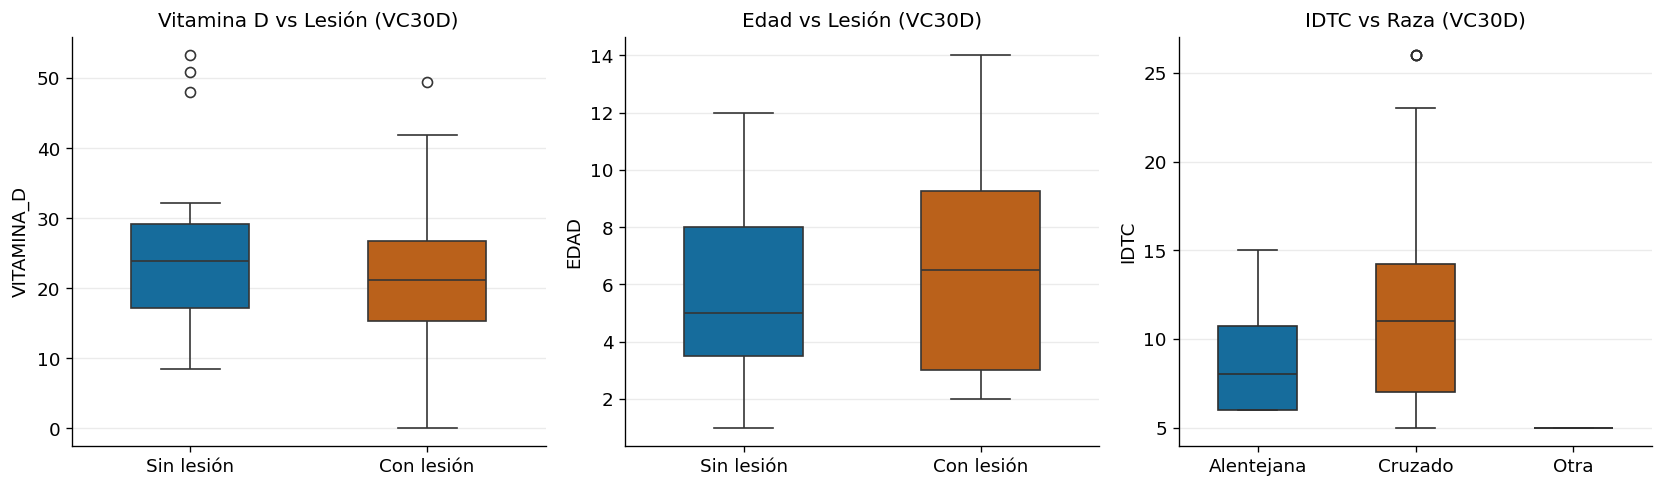

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Vitamina D vs Lesión
sns.boxplot(data=df, x="Lesiones_TB", y="VITAMINA_D", ax=axes[0], palette=PALETTE[:2], width=0.5)
axes[0].set_xticklabels(["Sin lesión", "Con lesión"])
axes[0].set_title(f"Vitamina D vs Lesión ({GRANJA})")
axes[0].set_xlabel("")

# Edad vs Lesión
sns.boxplot(data=df, x="Lesiones_TB", y="EDAD", ax=axes[1], palette=PALETTE[:2], width=0.5)
axes[1].set_xticklabels(["Sin lesión", "Con lesión"])
axes[1].set_title(f"Edad vs Lesión ({GRANJA})")
axes[1].set_xlabel("")

# IDTC vs Raza
razas = df["RAZA2"].unique()
if len(razas) >= 2:
    sns.boxplot(data=df, x="RAZA2", y="IDTC", ax=axes[2], palette=PALETTE, width=0.5)
    axes[2].set_title(f"IDTC vs Raza ({GRANJA})")
    axes[2].set_xlabel("")
else:
    sns.boxplot(data=df, x="Lesiones_TB", y="IDTC", ax=axes[2], palette=PALETTE[:2], width=0.5)
    axes[2].set_xticklabels(["Sin lesión", "Con lesión"])
    axes[2].set_title(f"IDTC vs Lesión ({GRANJA})")
    axes[2].set_xlabel("")

plt.tight_layout()
plt.savefig("figures/fig_04a_bivariate.png")
plt.show()

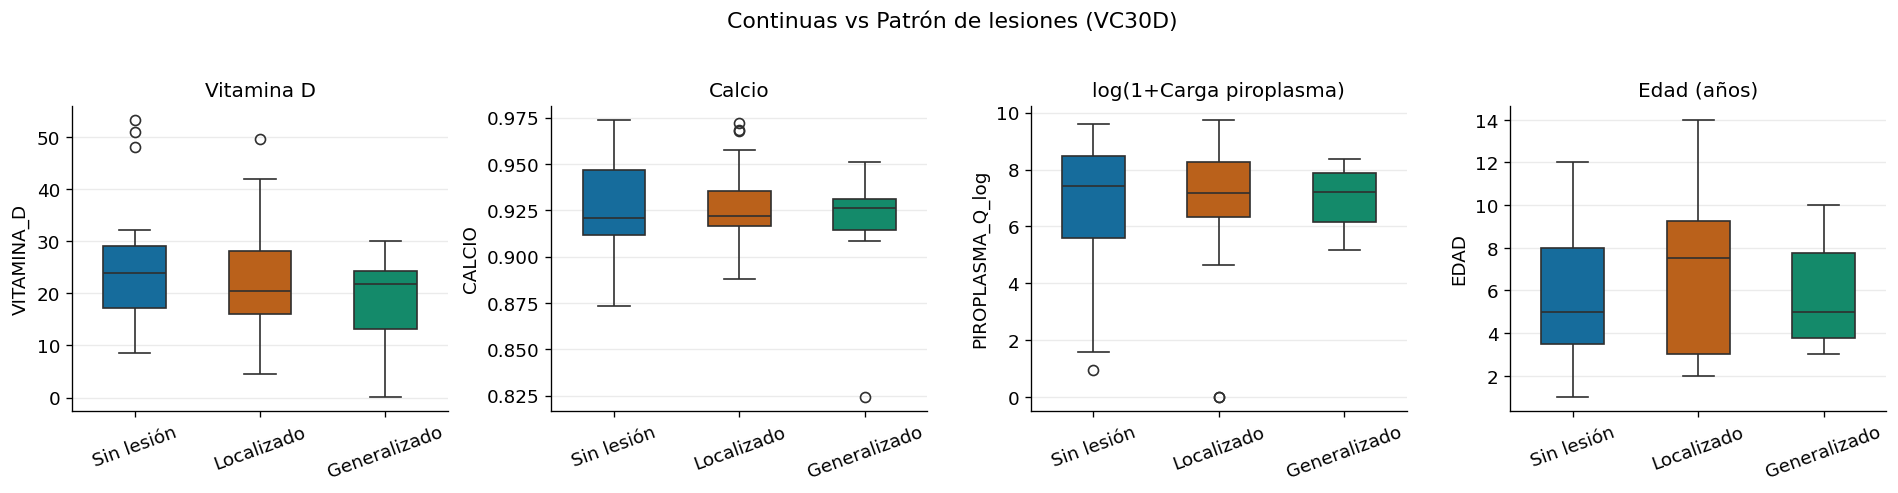

In [15]:
# Continuas vs Score_lesional (3 clases de Patron_lesiones_3)
cont_preds = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD"]
n_c = len(cont_preds)
df["patron_lab"] = df["Patron_lesiones"].map({-1: "Sin lesión", 0: "Localizado", 1: "Generalizado"})

fig, axes = plt.subplots(1, n_c, figsize=(4 * n_c, 4))
for ax, c in zip(axes, cont_preds):
    sns.boxplot(data=df, x="patron_lab", y=c, ax=ax,
                palette=PALETTE[:3], width=0.5,
                order=["Sin lesión", "Localizado", "Generalizado"])
    ax.set_title(tb.PRETTY.get(c, c))
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.suptitle(f"Continuas vs Patrón de lesiones ({GRANJA})", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_04a_cont_vs_patron.png", bbox_inches="tight")
plt.show()

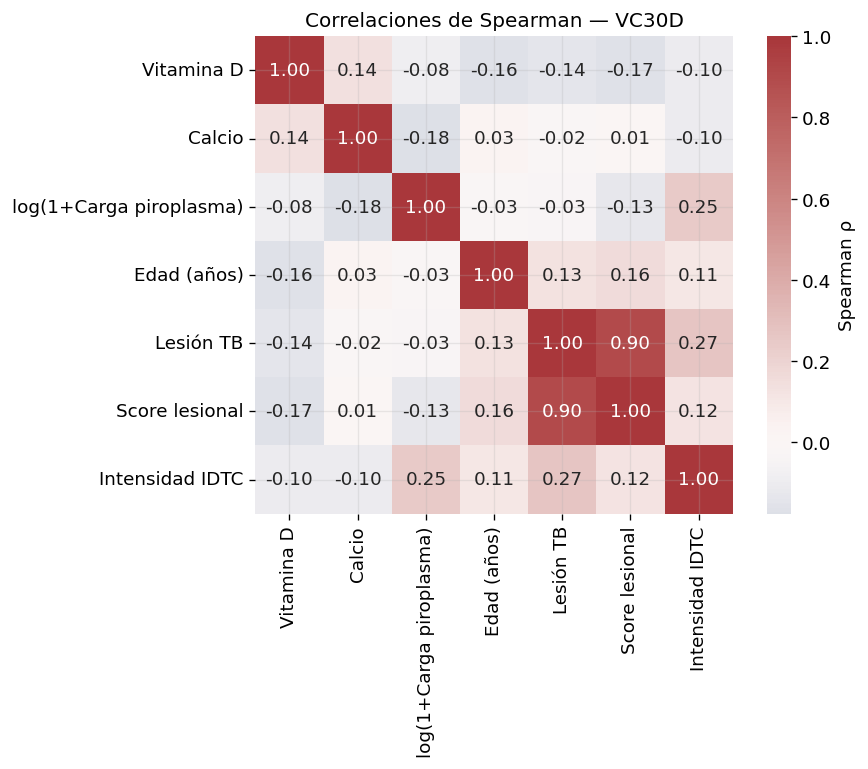

In [16]:
# Matriz de correlación de Spearman
numcols = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD",
           "Lesiones_TB", "Score_lesional", "IDTC"]
corr = df[numcols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
            cbar_kws={"label": "Spearman ρ"}, ax=ax,
            xticklabels=[tb.PRETTY.get(c, c) for c in numcols],
            yticklabels=[tb.PRETTY.get(c, c) for c in numcols])
ax.set_title(f"Correlaciones de Spearman — {GRANJA}")
plt.tight_layout()
plt.savefig("figures/fig_04a_corr.png")
plt.show()

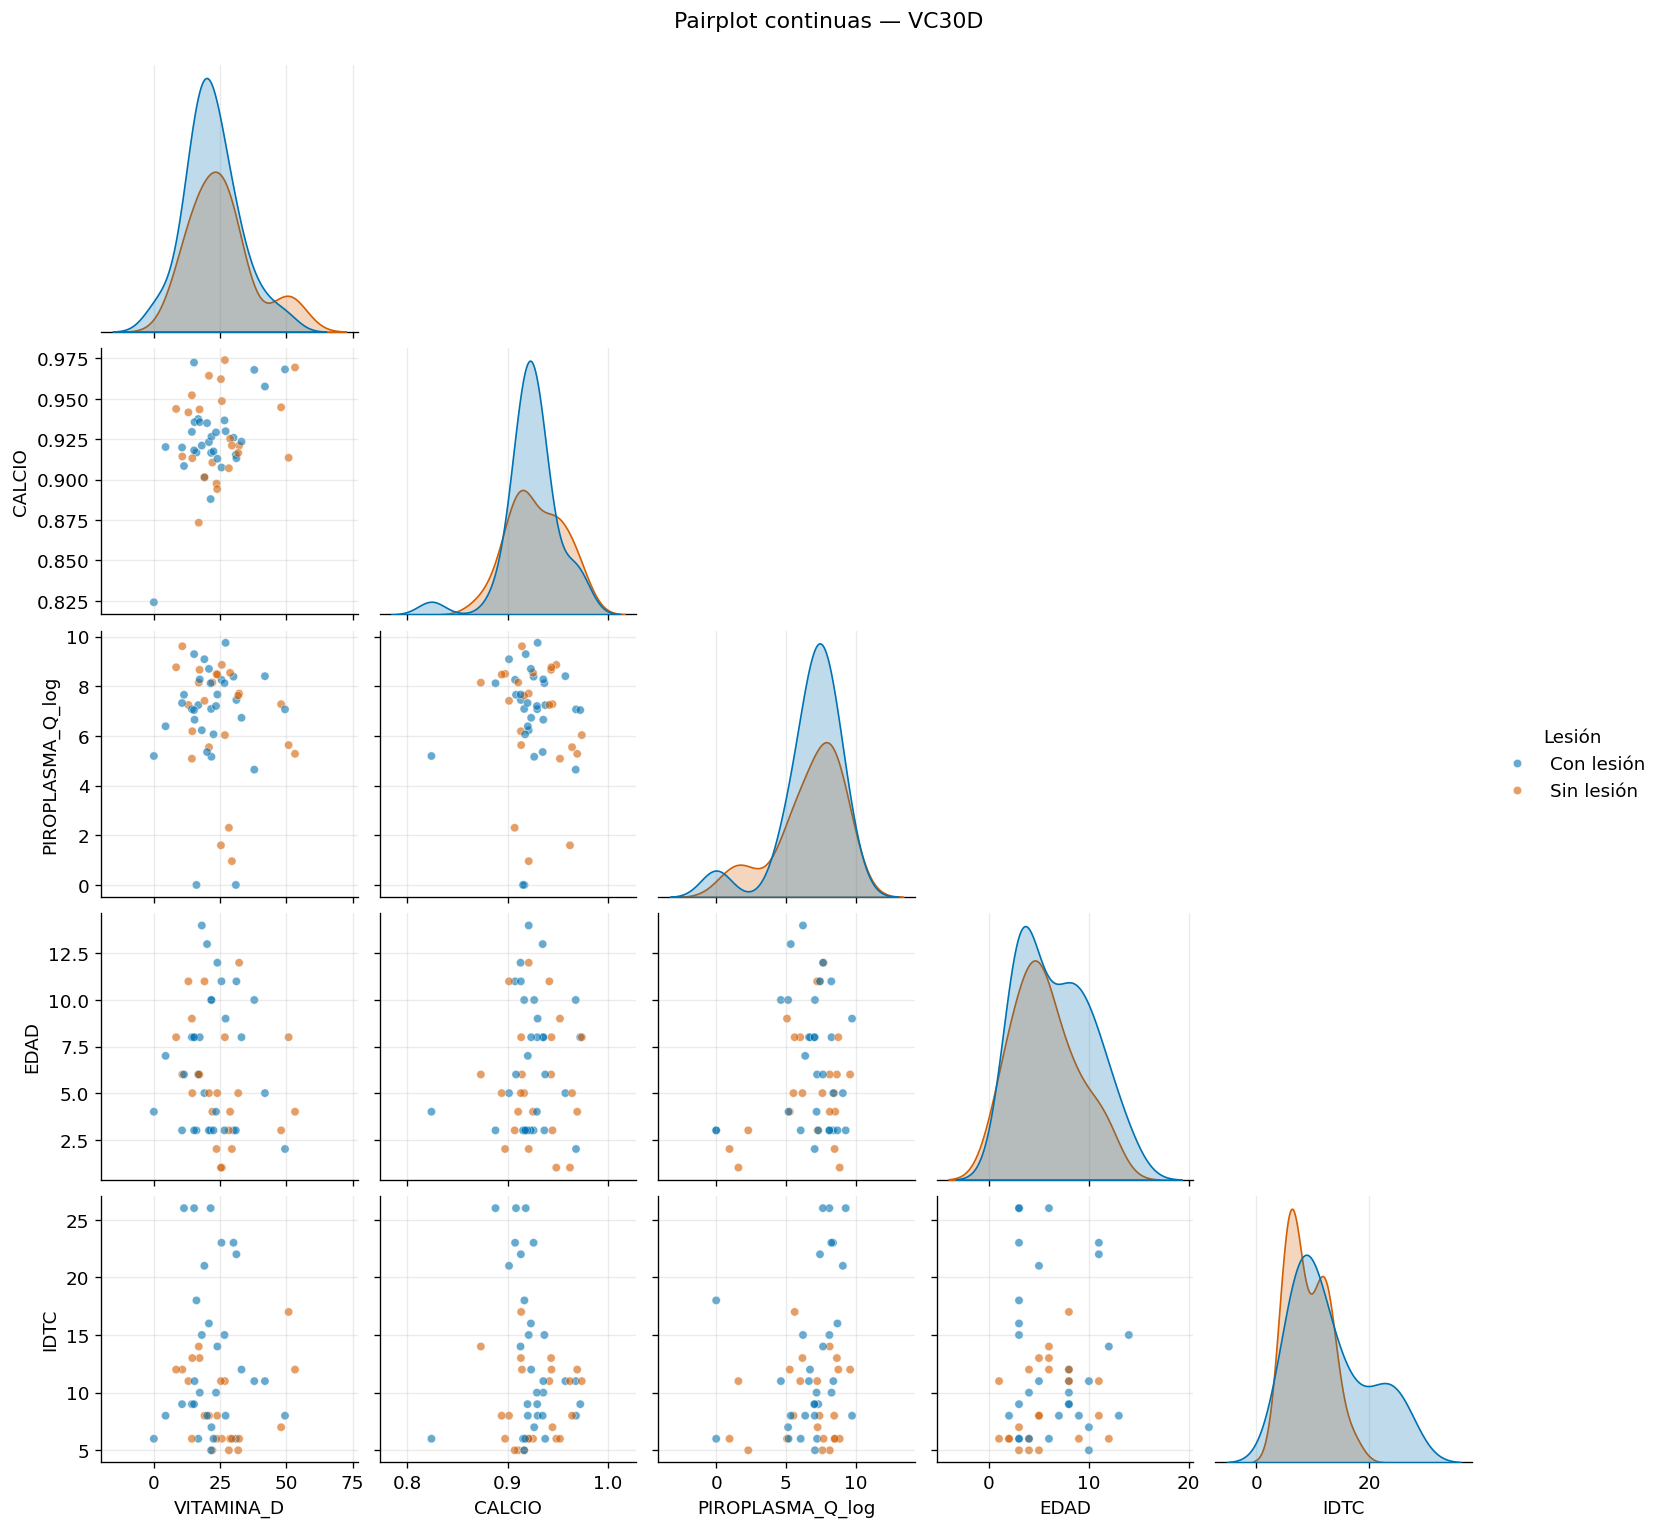

In [17]:
# Pairplot de continuas coloreado por Lesiones_TB
plot_cols = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD", "IDTC"]
df_plot = df[plot_cols + ["Lesiones_TB"]].dropna().copy()
df_plot["Lesión"] = df_plot["Lesiones_TB"].map({0: "Sin lesión", 1: "Con lesión"})

g = sns.pairplot(df_plot.drop("Lesiones_TB", axis=1),
                 hue="Lesión",
                 palette={"Sin lesión": PALETTE[1], "Con lesión": PALETTE[0]},
                 corner=True,
                 plot_kws={"alpha": 0.6, "s": 25},
                 diag_kind="kde")
g.figure.suptitle(f"Pairplot continuas — {GRANJA}", y=1.02)
g.figure.savefig("figures/fig_04a_pairplot.png", bbox_inches="tight")
plt.show()

## 8. Diagnóstico de desbalance y métricas recomendadas

Con n reducido en VC30D:
- **Prevalencia lesión** puede diferir de la cohorte global.
- `class_weight="balanced"` en RF sigue siendo recomendable.
- Métricas primarias: PR-AUC (con línea base = prevalencia intra-granja),
  ROC-AUC, Brier, MCC, Sens/Spec.

=== Desbalance en VC30D (n=55) ===
Prevalencia lesión TB       = 0.582  (línea base PR-AUC target 1)
Prevalencia generalizado|les= 0.250  (línea base PR-AUC target 2)
Proporción sin lesión / con lesión: 0.72:1

Distribución por clase (Lesiones_TB):
Lesiones_TB
Con lesión (1)    32
Sin lesión (0)    23


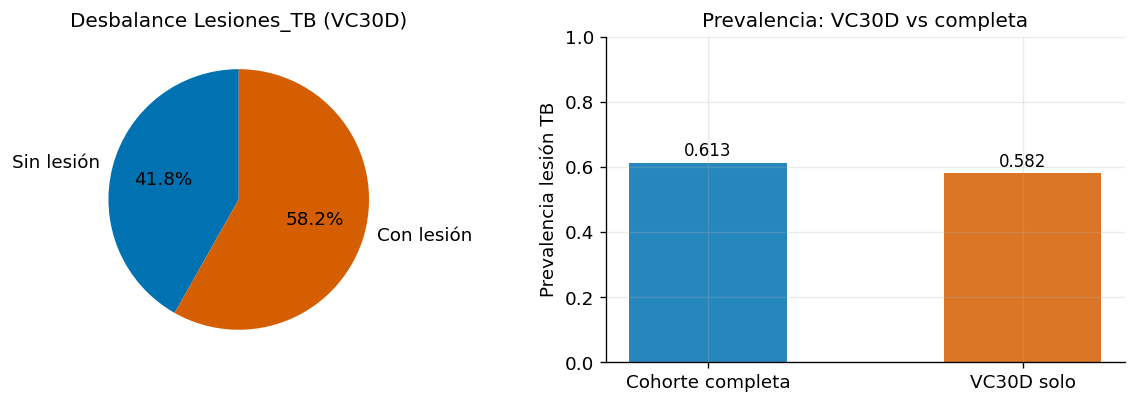


Métricas recomendadas para modelos VC30D:
  Target 1 (binaria): PR-AUC (base=0.582), ROC-AUC, MCC, Sens/Spec
  Target 2 (3 clases): BAL_ACC, ROC-AUC macro
  Targets 3/4 (reg.): Spearman r, R², RMSE


In [18]:
prev_les = df["Lesiones_TB"].mean()
prev_gen = df[df.Lesiones_TB==1]["Patron_lesiones"].mean() if df["Lesiones_TB"].sum() > 0 else np.nan

print(f"=== Desbalance en {GRANJA} (n={len(df)}) ===")
print(f"Prevalencia lesión TB       = {prev_les:.3f}  (línea base PR-AUC target 1)")
print(f"Prevalencia generalizado|les= {prev_gen:.3f}  (línea base PR-AUC target 2)")
print(f"Proporción sin lesión / con lesión: {(1-prev_les)/prev_les:.2f}:1")
print()
print("Distribución por clase (Lesiones_TB):")
vc = df["Lesiones_TB"].value_counts().rename({0:"Sin lesión (0)",1:"Con lesión (1)"})
print(vc.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Pie Lesiones_TB
axes[0].pie([1-prev_les, prev_les], labels=["Sin lesión","Con lesión"],
            autopct="%1.1f%%", colors=PALETTE[:2], startangle=90)
axes[0].set_title(f"Desbalance Lesiones_TB ({GRANJA})")

# Comparación prevalencias VC30D vs cohorte completa (antes de filtrar VC30D)
prev_full = df_full["Lesiones_TB"].mean()
axes[1].bar(["Cohorte completa", f"{GRANJA} solo"], [prev_full, prev_les],
            color=PALETTE[:2], alpha=0.85, width=0.5)
axes[1].set_ylabel("Prevalencia lesión TB")
axes[1].set_title(f"Prevalencia: {GRANJA} vs completa")
axes[1].set_ylim(0, 1)
for i, v in enumerate([prev_full, prev_les]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/fig_04a_balance.png")
plt.show()

print(f"\nMétricas recomendadas para modelos VC30D:")
print(f"  Target 1 (binaria): PR-AUC (base={prev_les:.3f}), ROC-AUC, MCC, Sens/Spec")
print(f"  Target 2 (3 clases): BAL_ACC, ROC-AUC macro")
print(f"  Targets 3/4 (reg.): Spearman r, R², RMSE")

## 9. Comparación intra-VC30D: lesionados vs no lesionados

In [19]:
# Estadísticos por grupo (lesionado / no lesionado) dentro de VC30D
grp = df.groupby("Lesiones_TB")
print(f"Estadísticos por grupo de lesión — {GRANJA}:")
for c in ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD", "IDTC"]:
    s0 = df[df.Lesiones_TB==0][c].dropna()
    s1 = df[df.Lesiones_TB==1][c].dropna()
    if len(s0) < 2 or len(s1) < 2: continue
    stat, p = stats.mannwhitneyu(s0, s1, alternative="two-sided")
    print(f"  {tb.PRETTY.get(c,c):25s}  SinLes: {s0.median():.2f} [IQR {s0.quantile(.25):.2f}–{s0.quantile(.75):.2f}]  "
          f"ConLes: {s1.median():.2f} [IQR {s1.quantile(.25):.2f}–{s1.quantile(.75):.2f}]  "
          f"p={p:.3f}")

# Dentro de lesionados: localizado vs generalizado
sub_les = df[df.Lesiones_TB==1].copy()
if len(sub_les[sub_les.Patron_lesiones==0]) >= 3 and len(sub_les[sub_les.Patron_lesiones==1]) >= 3:
    print(f"\nEstadísticos por patrón (solo lesionados, n={len(sub_les)}) — {GRANJA}:")
    for c in ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD", "IDTC"]:
        s0 = sub_les[sub_les.Patron_lesiones==0][c].dropna()
        s1 = sub_les[sub_les.Patron_lesiones==1][c].dropna()
        if len(s0) < 2 or len(s1) < 2: continue
        stat, p = stats.mannwhitneyu(s0, s1, alternative="two-sided")
        print(f"  {tb.PRETTY.get(c,c):25s}  Localiz: {s0.median():.2f}  General: {s1.median():.2f}  p={p:.3f}")

Estadísticos por grupo de lesión — VC30D:
  Vitamina D                 SinLes: 23.95 [IQR 17.15–29.14]  ConLes: 21.15 [IQR 15.37–26.79]  p=0.306
  Calcio                     SinLes: 0.92 [IQR 0.91–0.95]  ConLes: 0.92 [IQR 0.92–0.94]  p=0.905
  log(1+Carga piroplasma)    SinLes: 7.41 [IQR 5.59–8.48]  ConLes: 7.20 [IQR 6.31–8.19]  p=0.807
  Edad (años)                SinLes: 5.00 [IQR 3.50–8.00]  ConLes: 6.50 [IQR 3.00–9.25]  p=0.344
  Intensidad IDTC            SinLes: 8.00 [IQR 6.00–12.00]  ConLes: 10.50 [IQR 8.00–16.50]  p=0.046

Estadísticos por patrón (solo lesionados, n=32) — VC30D:
  Vitamina D                 Localiz: 20.47  General: 21.71  p=0.564
  Calcio                     Localiz: 0.92  General: 0.93  p=0.815
  log(1+Carga piroplasma)    Localiz: 7.16  General: 7.20  p=0.906
  Edad (años)                Localiz: 7.50  General: 5.00  p=0.612
  Intensidad IDTC            Localiz: 11.00  General: 8.50  p=0.432


In [20]:
# Tabla de contingencia serología × Lesiones_TB en VC30D
from scipy.stats import fisher_exact, chi2_contingency

print(f"Serología × Lesiones_TB — {GRANJA}:")
for c in ["PIROPLASMA", "THEILERIA", "ANAPLASMA"]:
    ct = pd.crosstab(df[c], df["Lesiones_TB"])
    if ct.shape == (2, 2):
        _, p = fisher_exact(ct)
        test = "Fisher"
    else:
        _, p, _, _ = chi2_contingency(ct)
        test = "Chi²"
    print(f"  {tb.PRETTY.get(c,c):25s}: {test}, p={p:.3f}")
    print(ct.to_string(), "\n")

Serología × Lesiones_TB — VC30D:
  Piroplasma (+)           : Fisher, p=0.502
Lesiones_TB   0   1
PIROPLASMA         
0.0           0   2
1.0          23  29 

  Theileria spp. (+)       : Fisher, p=0.785
Lesiones_TB   0   1
THEILERIA          
0.0          10  16
1.0          13  16 

  Anaplasma spp. (+)       : Fisher, p=0.036
Lesiones_TB   0   1
ANAPLASMA          
0.0           3  13
1.0          20  19 



## 10. Conclusiones del EDA — VC30D

### Resumen numérico

In [21]:
print(f"=== Resumen EDA — {GRANJA} ===")
print(f"  n animales (tras limpieza): {len(df)}")
print(f"  Prevalencia lesión TB:      {df['Lesiones_TB'].mean():.3f}")
print(f"  Patrón generalizado|lesión: {df[df.Lesiones_TB==1]['Patron_lesiones'].mean():.3f}")
print(f"  Score lesional (mediana):   {df['Score_lesional'].median():.1f}")
print(f"  IDTC (mediana):             {df['IDTC'].median():.1f} mm")
print()

# Comparación VC30D vs nb01 (cohorte completa)
df_full_filt = df_full.copy()
df_full_filt = df_full_filt[df_full_filt[["PIROPLASMA","THEILERIA","ANAPLASMA",
                                          "VITAMINA_D","CALCIO","PIROPLASMA_Q"]].isna().sum(axis=1) < 4]
print("  Comparación prevalencia lesión:")
print(f"    Cohorte completa (n={len(df_full_filt)}): {df_full_filt['Lesiones_TB'].mean():.3f}")
print(f"    Solo VC30D       (n={len(df)}):  {df['Lesiones_TB'].mean():.3f}")
print()
print("  Interpretación:")
print(f"  - Al eliminar la mezcla inter-granja, las asociaciones bivariantes")
print(f"    pueden cambiar respecto al nb01 (pueden aparecer o desaparecer).")
print(f"  - Con n≈{len(df)} la potencia estadística bivariante es baja; los")
print(f"    modelos RF (nb04c–04f) pueden capturar señal multivariante que")
print(f"    los tests univariantes no detectan.")
print(f"  - Si las métricas RF intra-VC30D son similares a las de nb02x,")
print(f"    la señal era genuinamente intra-granja y no confundida.")

=== Resumen EDA — VC30D ===
  n animales (tras limpieza): 55
  Prevalencia lesión TB:      0.582
  Patrón generalizado|lesión: 0.250
  Score lesional (mediana):   1.0
  IDTC (mediana):             10.0 mm

  Comparación prevalencia lesión:
    Cohorte completa (n=103): 0.612
    Solo VC30D       (n=55):  0.582

  Interpretación:
  - Al eliminar la mezcla inter-granja, las asociaciones bivariantes
    pueden cambiar respecto al nb01 (pueden aparecer o desaparecer).
  - Con n≈55 la potencia estadística bivariante es baja; los
    modelos RF (nb04c–04f) pueden capturar señal multivariante que
    los tests univariantes no detectan.
  - Si las métricas RF intra-VC30D son similares a las de nb02x,
    la señal era genuinamente intra-granja y no confundida.


### Conclusiones narrativas

1. **Prevalencia:** VC30D presenta una prevalencia de lesión TB diferente a la
   cohorte global; esto afecta la línea base de PR-AUC que deben usar los modelos 04c–04f.

2. **Señal bivariante intra-granja:** Sin el confusor inter-granja, las asociaciones
   bivariantes pueden diferir del EDA completo (nb01). Una señal significativa en VC30D
   sería más robusta; una señal que desaparece sugiere que era artefacto entre-granja.

3. **Potencia:** n≈50 es bajo para corrección FDR en múltiples tests. Los tests
   bivariantes tienen potencia reducida; interpretar los p-valores crudos (antes de
   corrección) como exploratorios.

4. **Expl como predictor:** Al restringir a VC30D, `Expl` es constante y no puede
   usarse como predictor en los modelos 04x (a diferencia de los 03x).

5. **Próximos pasos:** Modelos RF con CV por animal en VC30D (notebooks 04c–04f);
   comparar sus métricas con nb02x y nb03x para cuantificar el efecto inter-granja.